In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from scipy.stats import entropy

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
pd.set_option('display.max_columns', None)

data= pd.read_csv("anti_total.csv", index_col=False)

In [4]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
data['ROOMNO'] = data['ROOMNO'].map(roomno_mapping)          

data['SEX'] = data['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    data[col] = data[col].map({'Y': 1, 'N': 0})

In [5]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [6]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [7]:
final_cols = col_sum[col_sum >= 500].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [8]:
feature_cols = list(set(data_filter.columns) - set(abx_cols))
X = data_filter[feature_cols]
y = data_filter[final_cols]

In [9]:
X.columns

Index(['Bacteria level', 'INTIME', 'OTHERINFECTIONSITE_flag', 'CANCER',
       'CHECKITEM32SCORE', 'INFECTIONSITE4', 'ISSEPSIS0', 'HST', 'AUTOIMMUNE',
       'STAYTIME', 'Hb', 'INFECTIONSITE1', 'VITALSIGNSDBP', 'INFECTIONSITE5',
       'CHECKITEM28A', 'Neutrophil Seg.', 'Microscopic RBC level',
       'VITALSIGNSRR', 'WBC', 'Absolute Neutrophil count', 'PT', 'INR', 'DM',
       'T.Bilirubin', 'INJURELEVEL', 'K', 'INFECTIONSITE3', 'CARDIOVASCULAR',
       'ROOMNO', 'GPT', 'CRP', 'VITALSIGNSGCS', 'CHECKITEM27SCORE', 'SEX',
       'PH', 'Creatinine', 'CHECKITEM31SCORE', 'APTT', 'CHECKITEM29SCORE',
       'Na', 'CNS', 'MAP', 'CHECKITEM27', 'VITALSIGNSPR', 'Nitrite level',
       'LIVER', 'VITALSIGNSBT', 'BE(ecf)', 'Influenza Virus A level',
       'INFECTIONSITE2', 'INFECTIONSITE9', 'PCO2', 'Ht', 'AGE',
       'VITALSIGNSSPO2', 'PLT', 'ACCOUNTNO', 'KIDNEY', 'Leukocyte level',
       'O2 SAT', 'CHECKITEM30SCORE', 'CHECKITEM28SCORE',
       'Microscopic WBC level', 'FEVER', 'RESPIRATORY', 'L

In [10]:
# 挑出'INFECTIONSITE1','INFECTIONSITE2','INFECTIONSITE3','INFECTIONSITE4','INFECTIONSITE5','INFECTIONSITE9'的元素都是0，但是
# 'OTHERINFECTIONSITE_flag'是1的樣本?

# 1. 定義要檢查為 0 的欄位清單
main_sites = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9'
]

# 2. 設定篩選條件
# 條件 A：main_sites 裡面的所有元素都要是 0
# 條件 B：OTHERINFECTIONSITE_flag 必須是 1
condition_A = (X[main_sites] == 0).all(axis=1)
condition_B = (X['OTHERINFECTIONSITE_flag'] == 1)

# 3. 取得樣本
other_only_samples = X[condition_A & condition_B].copy()

# 印出數量確認
print(f"符合『僅有其他感染部位』的樣本數：{len(other_only_samples)}")


符合『僅有其他感染部位』的樣本數：0


In [11]:
# 定義所有感染部位欄位
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9', 
    'OTHERINFECTIONSITE_flag'
]

# 篩選出所有部位都是 0 的列
no_site_mask = (X[all_site_cols] == 0).all(axis=1)
no_site_samples = X[no_site_mask]

# 取得這些樣本的 ACCOUNTNO
no_site_accounts = no_site_samples['ACCOUNTNO'].unique()

print(f"總樣本數: {len(X)}")
print(f"部位全為 0 的樣本數: {len(no_site_samples)}")
print(f"這些樣本對應的不重複病患數: {len(no_site_accounts)}")
print(f"佔比: {len(no_site_samples)/len(X):.2%}")


總樣本數: 27968
部位全為 0 的樣本數: 16088
這些樣本對應的不重複病患數: 16088
佔比: 57.52%


In [12]:
# site_cols

site_cols = [
'INFECTIONSITE1',
'INFECTIONSITE2',
'INFECTIONSITE3',
'INFECTIONSITE4',
'INFECTIONSITE5',
'INFECTIONSITE9',
'OTHERINFECTIONSITE_flag'
]

drug_cols = y.columns
# case number
site_counts = X[site_cols].sum()
print(site_counts)

INFECTIONSITE1             5879
INFECTIONSITE2             4505
INFECTIONSITE3             3066
INFECTIONSITE4              270
INFECTIONSITE5             1480
INFECTIONSITE9              598
OTHERINFECTIONSITE_flag     495
dtype: int64


In [13]:
# 單一抗生素 vs infection site entropy

# 也就是：

# 某抗生素 → infection site 是否固定

drug_entropy = []

for drug in drug_cols:
    
    mask = y[drug] == 1
    
    if mask.sum() == 0:
        continue
    
    # infection site distribution
    site_dist = X.loc[mask, site_cols].sum()
    
    probs = site_dist / site_dist.sum()
    
    ent = entropy(probs, base=2)
    
    drug_entropy.append({
        "drug": drug,
        "entropy": ent,
        "cases": mask.sum()
    })

drug_entropy_df = pd.DataFrame(drug_entropy)

drug_entropy_df = drug_entropy_df.sort_values("entropy")

print(drug_entropy_df)

                           drug   entropy  cases
9                    Cephalexin  1.159555    517
1                  Azithromycin  1.195715   2053
17                    Peramivir  1.286283   1119
16                  Oseltamivir  1.496641    835
15                Metronidazole  1.532432   1020
14                 Levofloxacin  1.596597    720
11                  Clindamycin  1.774726    624
10                Ciprofloxacin  1.959192   2071
6        Cefoperazone/sulbactam  1.959447   1412
0   Amoxicillin/Clavulanic acid  1.986123   5515
3                    Cefadroxil  1.998129    918
12                     Flomoxef  2.021881   5196
5                      Cefixime  2.065759   2166
8                    Cefuroxime  2.068939   1691
18      Piperacillin/Tazobactam  2.163966   1511
2            Baloxavir marboxil  2.187670   1085
13                   Gentamicin  2.436392    623
7                   Ceftriaxone  2.437502    610
4                     Cefazolin  2.481190   2371


In [14]:
from sklearn.metrics import mutual_info_score

for i in y.columns:
    mi = mutual_info_score(X['INFECTIONSITE9'], y[i])
    print(mi)

2.8137371037729314e-05
0.0003159050208895991
0.0007050193312329268
0.0007214605703378882
0.00017482686027593154
1.2506224636001442e-05
0.0006557752536274688
0.0008657636687494277
0.00012398541684514007
0.00040331415351554933
0.0002946600725641296
0.0002904874865099572
0.0019697411973898446
1.4540265386294923e-07
1.913512584269389e-07
6.536926049997838e-05
0.0005145827147801964
0.00047557703658187276
0.0014710009159566856


In [15]:
# heatmap_data: P(drug | site)

import pandas as pd

heatmap_data = pd.DataFrame(index=site_cols, columns=drug_cols)

for site in site_cols:
    
    mask = X[site] == 1
    
    if mask.sum() == 0:
        continue
    
    probs = y[mask].mean()
    
    heatmap_data.loc[site] = probs

heatmap_data = heatmap_data.astype(float)

# 平均使用率
drug_order = heatmap_data.mean().sort_values(ascending=False).index

heatmap_data = heatmap_data[drug_order]
print(heatmap_data)
heatmap_data.to_csv('heatmap_data.csv')

                         Flomoxef  Amoxicillin/Clavulanic acid  \
INFECTIONSITE1           0.363327                     0.131655   
INFECTIONSITE2           0.629079                     0.025083   
INFECTIONSITE3           0.444227                     0.024136   
INFECTIONSITE4           0.148148                     0.081481   
INFECTIONSITE5           0.194595                     0.522297   
INFECTIONSITE9           0.366221                     0.177258   
OTHERINFECTIONSITE_flag  0.331313                     0.189899   

                         Piperacillin/Tazobactam  Cefoperazone/sulbactam  \
INFECTIONSITE1                          0.165845                0.169076   
INFECTIONSITE2                          0.148058                0.071254   
INFECTIONSITE3                          0.131442                0.160470   
INFECTIONSITE4                          0.114815                0.059259   
INFECTIONSITE5                          0.116216                0.050000   
INFECTIONSITE9 

In [16]:
# heatmap_data2: P(site | drug)

heatmap_data2 = pd.DataFrame(index=drug_cols, columns=site_cols)

for drug in drug_cols:

    mask = y[drug] == 1

    if mask.sum() == 0:
        continue

    probs = X.loc[mask, site_cols].mean()

    heatmap_data2.loc[drug] = probs

heatmap_data2 = heatmap_data2.astype(float)
print(heatmap_data2)

                             INFECTIONSITE1  INFECTIONSITE2  INFECTIONSITE3  \
Amoxicillin/Clavulanic acid        0.140345        0.020490        0.013418   
Azithromycin                       0.323916        0.035071        0.027277   
Baloxavir marboxil                 0.010138        0.006452        0.004608   
Cefadroxil                         0.003268        0.007625        0.013072   
Cefazolin                          0.095740        0.090257        0.066639   
Cefixime                           0.114497        0.172207        0.101570   
Cefoperazone/sulbactam             0.703966        0.227337        0.348442   
Ceftriaxone                        0.445902        0.455738        0.211475   
Cefuroxime                         0.060911        0.125370        0.141336   
Cephalexin                         0.003868        0.005803        0.023211   
Ciprofloxacin                      0.082569        0.209561        0.180106   
Clindamycin                        0.125000        0

In [17]:
len(X), len(X['ACCOUNTNO'].unique())

(27968, 27968)

In [18]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME'])

In [19]:
# X['CRP_flag'] = (
#     X['CRP'].fillna('').str.strip().ne('').astype(int)
# )

# X['PH_flag'] = (
#     X['PH'].fillna('').str.strip().ne('').astype(int)
# )

# X['T.Bilirubin_flag'] = (
#     X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int)
# )

# X['INR_flag'] = (
#     X['INR'].fillna('').str.strip().ne('').astype(int)
# )

# X['PT_flag'] = (
#     X['PT'].fillna('').str.strip().ne('').astype(int)
# )

# X['APTT_flag'] = (
#     X['APTT'].fillna('').str.strip().ne('').astype(int)
# )

# X['PCO2_flag'] = (
#     X['PCO2'].fillna('').str.strip().ne('').astype(int)
# )

# X['HCO3_flag'] = (
#     X['HCO3'].fillna('').str.strip().ne('').astype(int)
# )

# X['BE(ecf)_flag'] = (
#     X['BE(ecf)'].fillna('').str.strip().ne('').astype(int)
# )

# X['O2 SAT_flag'] = (
#     X['O2 SAT'].fillna('').str.strip().ne('').astype(int)
# )

# ##########################################################

# X['Leukocyte level_flag'] = (
#     X['Leukocyte level'].fillna('').str.strip().ne('').astype(int)
# )

# X['Nitrite level_flag'] = (
#     X['Nitrite level'].fillna('').str.strip().ne('').astype(int)
# )

# X['Bacteria level_flag'] = (
#     X['Bacteria level'].fillna('').str.strip().ne('').astype(int)
# )

# X['Microscopic RBC level_flag'] = (
#     X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int)
# )

# X['Microscopic WBC level_flag'] = (
#     X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int)
# )

# X['PH_flag'] = (
#     X['PH'].fillna('').str.strip().ne('').astype(int)
# )

# X['Influenza Virus A level_flag'] = (
#     X['Influenza Virus A level'].fillna('').str.strip().ne('').astype(int)
# )

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.1, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((25171, 64), (25171, 19), (2797, 64), (2797, 19))

In [21]:
X_train.isnull().sum(), X_test.isnull().sum()

(Bacteria level             22137
 OTHERINFECTIONSITE_flag        0
 CANCER                         0
 CHECKITEM32SCORE           20781
 INFECTIONSITE4                 0
                            ...  
 Microscopic WBC level      22137
 FEVER                          0
 RESPIRATORY                    0
 Lymphocyte                 18741
 HCO3                       23835
 Length: 64, dtype: int64,
 Bacteria level             2467
 OTHERINFECTIONSITE_flag       0
 CANCER                        0
 CHECKITEM32SCORE           2288
 INFECTIONSITE4                0
                            ... 
 Microscopic WBC level      2467
 FEVER                         0
 RESPIRATORY                   0
 Lymphocyte                 2088
 HCO3                       2636
 Length: 64, dtype: int64)

In [22]:
# a = X_train.isnull().sum()
# a.to_csv('X null')

In [23]:
X_train.dtypes, X_test.dtypes

(Bacteria level             float64
 OTHERINFECTIONSITE_flag      int64
 CANCER                       int64
 CHECKITEM32SCORE           float64
 INFECTIONSITE4               int64
                             ...   
 Microscopic WBC level      float64
 FEVER                        int64
 RESPIRATORY                  int64
 Lymphocyte                 float64
 HCO3                       float64
 Length: 64, dtype: object,
 Bacteria level             float64
 OTHERINFECTIONSITE_flag      int64
 CANCER                       int64
 CHECKITEM32SCORE           float64
 INFECTIONSITE4               int64
                             ...   
 Microscopic WBC level      float64
 FEVER                        int64
 RESPIRATORY                  int64
 Lymphocyte                 float64
 HCO3                       float64
 Length: 64, dtype: object)

In [24]:
y_train.sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    4990.0
Flomoxef                       4650.0
Cefazolin                      2151.0
Cefixime                       1962.0
Ciprofloxacin                  1860.0
Azithromycin                   1843.0
Cefuroxime                     1541.0
Piperacillin/Tazobactam        1356.0
Cefoperazone/sulbactam         1278.0
Peramivir                      1013.0
Baloxavir marboxil              977.0
Metronidazole                   923.0
Cefadroxil                      816.0
Oseltamivir                     745.0
Levofloxacin                    650.0
Clindamycin                     560.0
Gentamicin                      556.0
Ceftriaxone                     551.0
Cephalexin                      465.0
dtype: float64

In [25]:
X_train.columns

Index(['Bacteria level', 'OTHERINFECTIONSITE_flag', 'CANCER',
       'CHECKITEM32SCORE', 'INFECTIONSITE4', 'ISSEPSIS0', 'HST', 'AUTOIMMUNE',
       'STAYTIME', 'Hb', 'INFECTIONSITE1', 'VITALSIGNSDBP', 'INFECTIONSITE5',
       'CHECKITEM28A', 'Neutrophil Seg.', 'Microscopic RBC level',
       'VITALSIGNSRR', 'WBC', 'Absolute Neutrophil count', 'PT', 'INR', 'DM',
       'T.Bilirubin', 'INJURELEVEL', 'K', 'INFECTIONSITE3', 'CARDIOVASCULAR',
       'GPT', 'CRP', 'VITALSIGNSGCS', 'CHECKITEM27SCORE', 'SEX', 'PH',
       'Creatinine', 'CHECKITEM31SCORE', 'APTT', 'CHECKITEM29SCORE', 'Na',
       'CNS', 'MAP', 'CHECKITEM27', 'VITALSIGNSPR', 'Nitrite level', 'LIVER',
       'VITALSIGNSBT', 'BE(ecf)', 'Influenza Virus A level', 'INFECTIONSITE2',
       'INFECTIONSITE9', 'PCO2', 'Ht', 'AGE', 'VITALSIGNSSPO2', 'PLT',
       'KIDNEY', 'Leukocyte level', 'O2 SAT', 'CHECKITEM30SCORE',
       'CHECKITEM28SCORE', 'Microscopic WBC level', 'FEVER', 'RESPIRATORY',
       'Lymphocyte', 'HCO3'],
      dtype=

In [26]:
# 轉數值
num_cols = ['Neutrophil Seg.', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'WBC', 
            'Lymphocyte', 'CRP', 'Hb', 'Creatinine', 'PCO2', 'INR', 'Absolute Neutrophil count', 'Ht', 'HST', 'BE(ecf)', 'T.Bilirubin',
           'Na', 'K', 'GPT', 'O2 SAT', 'HCO3', 'PT', 'APTT', 'PLT']
# num_cols = ['Neutrophil Seg.', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'WBC', 
#             'Lymphocyte', 'Hb', 'Creatinine', 'Absolute Neutrophil count', 'Ht', 'HST','Na', 'K', 'GPT', 'PLT', 'Ht']
for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [27]:
# vital sign impute
vital_cols = ['Neutrophil Seg.', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'WBC', 
            'Lymphocyte', 'CRP', 'Hb', 'Creatinine', 'PCO2', 'INR', 'Absolute Neutrophil count', 'Ht', 'HST', 'BE(ecf)', 'T.Bilirubin',
           'Na', 'K', 'GPT', 'O2 SAT', 'HCO3', 'PT', 'APTT', 'PLT']
# vital_cols = ['Neutrophil Seg.', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'WBC', 
#             'Lymphocyte', 'Hb', 'Creatinine', 'Absolute Neutrophil count', 'Ht', 'HST','Na', 'K', 'GPT', 'PLT', 'Ht']

for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

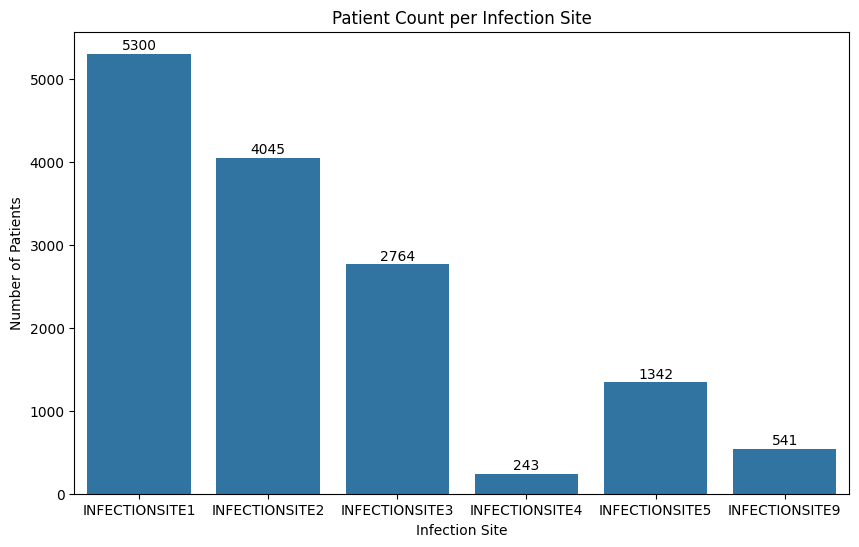

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = X_train
infection_sites = [
    'INFECTIONSITE1','INFECTIONSITE2','INFECTIONSITE3',
    'INFECTIONSITE4','INFECTIONSITE5','INFECTIONSITE9'
]

site_counts = []

for col in infection_sites:
    count = (df[col] > 0).sum()
    site_counts.append(count)

site_counts = pd.DataFrame({
    "Infection_Site": infection_sites,
    "Patient_Count": site_counts
})

plt.figure(figsize=(10,6))
sns.barplot(data=site_counts, x="Infection_Site", y="Patient_Count")

for i,v in enumerate(site_counts["Patient_Count"]):
    plt.text(i, v+50, str(v), ha='center')

plt.title("Patient Count per Infection Site")
plt.ylabel("Number of Patients")
plt.xlabel("Infection Site")

plt.show()

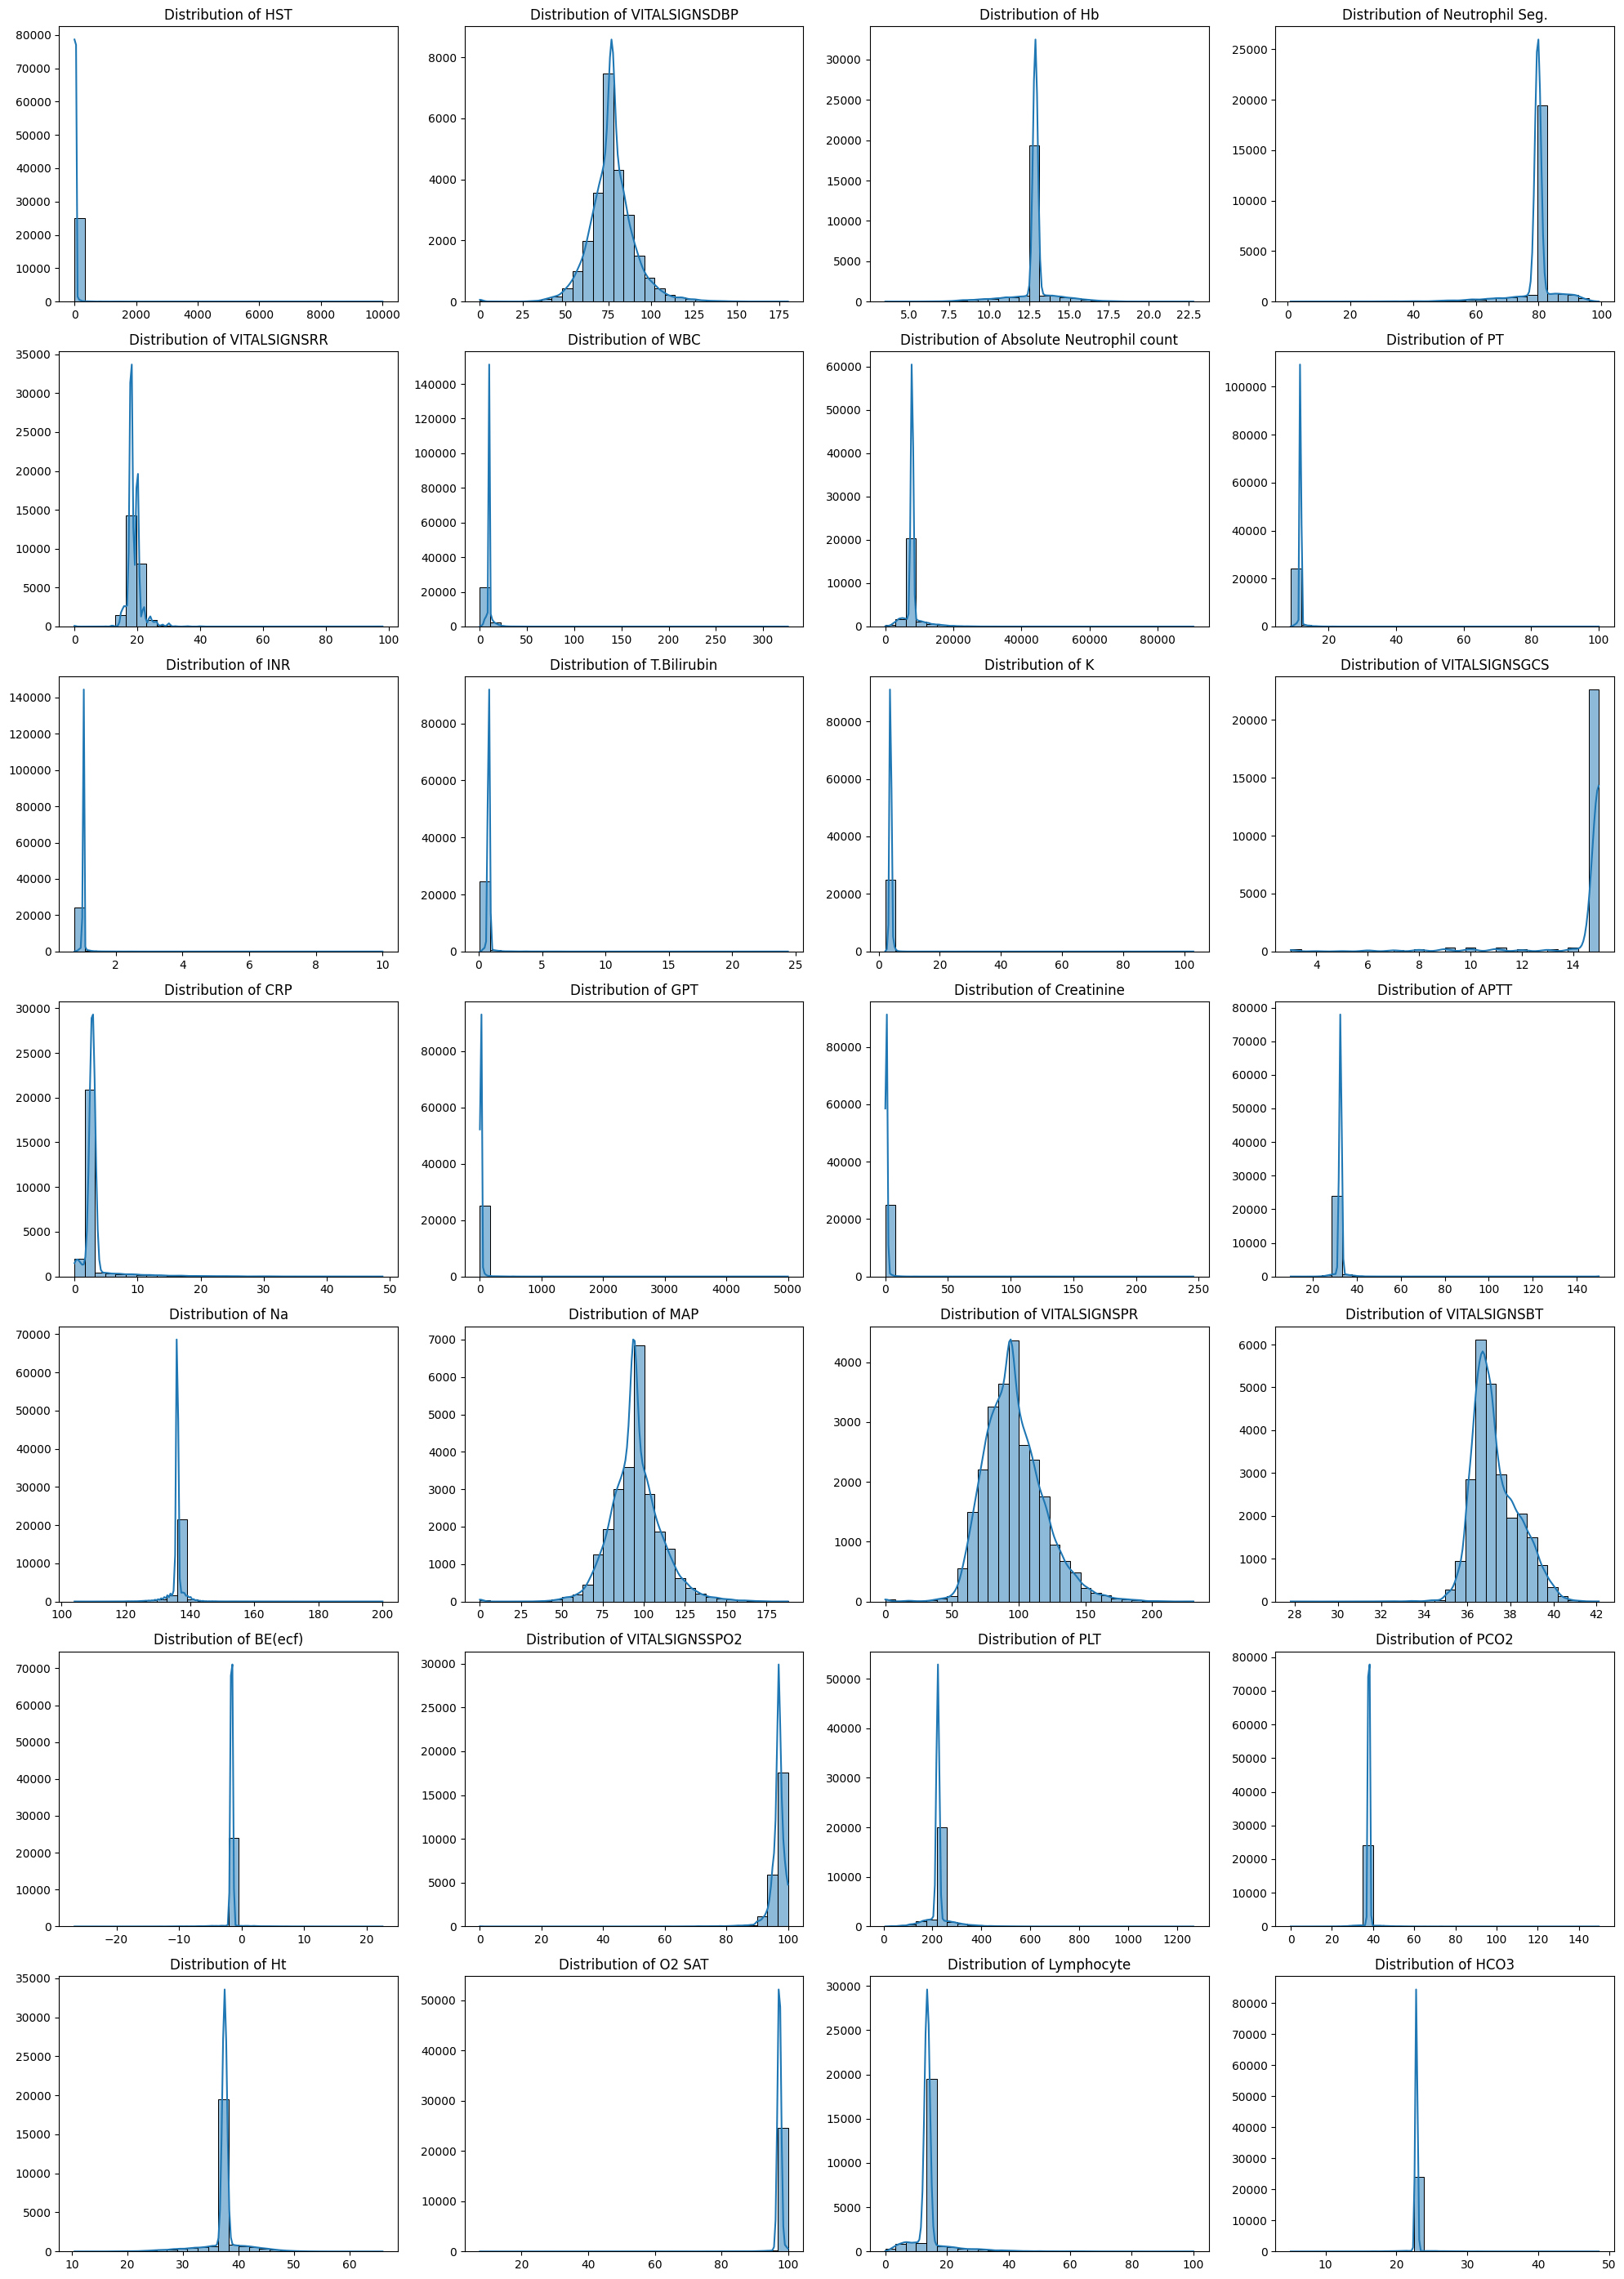

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 你的特徵列表（已去重）
vital_cols = list(set(['Neutrophil Seg.', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 
              'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'WBC', 'Lymphocyte', 'CRP', 'Hb', 
              'Creatinine', 'PCO2', 'INR', 'Absolute Neutrophil count', 'Ht', 'HST', 
              'BE(ecf)', 'T.Bilirubin', 'Na', 'K', 'GPT', 'O2 SAT', 'HCO3', 'PT', 'APTT', 'PLT']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

<Axes: >

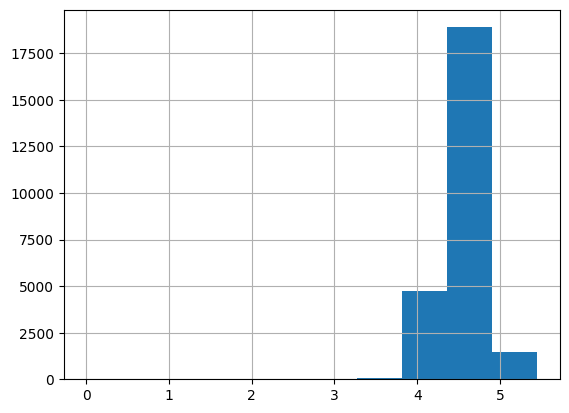

In [31]:
np.log1p(X_train['VITALSIGNSPR']).hist()

In [32]:
# X_train['log_CRP'] = np.log1p(X_train['CRP'])
# X_test['log_CRP'] = np.log1p(X_test['CRP'])

# X_train['log_T.Bilirubin'] = np.log1p(X_train['T.Bilirubin'])
# X_test['log_T.Bilirubin'] = np.log1p(X_test['T.Bilirubin'])

# X_train['log_O2 SAT'] = np.log1p(X_train['O2 SAT'])
# X_test['log_O2 SAT'] = np.log1p(X_test['O2 SAT'])

# X_train['log_WBC'] = np.log1p(X_train['WBC'])
# X_test['log_WBC'] = np.log1p(X_test['WBC'])

# X_train['log_GPT'] = np.log1p(X_train['GPT'])
# X_test['log_GPT'] = np.log1p(X_test['GPT'])

# X_train['log_PT'] = np.log1p(X_train['PT'])
# X_test['log_PT'] = np.log1p(X_test['PT'])

# X_train['log_PLT'] = np.log1p(X_train['PLT'])
# X_test['log_PLT'] = np.log1p(X_test['PLT'])

# X_train['log_Creatinine'] = np.log1p(X_train['Creatinine'])
# X_test['log_Creatinine'] = np.log1p(X_test['Creatinine'])

# X_train['log_APTT'] = np.log1p(X_train['APTT'])
# X_test['log_APTT'] = np.log1p(X_test['APTT'])

# X_train['log_HST'] = np.log1p(X_train['HST'])
# X_test['log_HST'] = np.log1p(X_test['HST'])

# X_train['log_Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
# X_test['log_Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

# X_train['log_K'] = np.log1p(X_train['K'])
# X_test['log_K'] = np.log1p(X_test['K'])

# X_train['log_Na'] = np.log1p(X_train['Na'])
# X_test['log_Na'] = np.log1p(X_test['Na'])

# X_train['log_Lymphocyte'] = np.log1p(X_train['Lymphocyte'])
# X_test['log_Lymphocyte'] = np.log1p(X_test['Lymphocyte'])

# X_train['log_Neutrophil Seg.'] = np.log1p(X_train['Neutrophil Seg.'])
# X_test['log_Neutrophil Seg.'] = np.log1p(X_test['Neutrophil Seg.'])

# X_train['log_Hb'] = np.log1p(X_train['Hb'])
# X_test['log_Hb'] = np.log1p(X_test['Hb'])

# X_train['log_Ht'] = np.log1p(X_train['Ht'])
# X_test['log_Ht'] = np.log1p(X_test['Ht'])

# X_train['log_PCO2'] = np.log1p(X_train['PCO2'])
# X_test['log_PCO2'] = np.log1p(X_test['PCO2'])

# X_train['log_VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
# X_test['log_VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

# X_train['log_VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
# X_test['log_VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

# X_train['log_VITALSIGNSPR'] = np.log1p(X_train['VITALSIGNSPR'])
# X_test['log_VITALSIGNSPR'] = np.log1p(X_test['VITALSIGNSPR'])

# X_train['log_VITALSIGNSDBP'] = np.log1p(X_train['VITALSIGNSDBP'])
# X_test['log_VITALSIGNSDBP'] = np.log1p(X_test['VITALSIGNSDBP'])

# X_train['log_VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
# X_test['log_VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

In [33]:
drop_cols = ['CHECKITEM28A', 'CHECKITEM27'] #, 'CRP', 'T.Bilirubin', 'WBC', 'GPT', 'PT', 'PLT', 'Creatinine', 'APTT', 'HST',
            # 'Absolute Neutrophil count', 'K', 'Na', 'Lymphocyte', 'Neutrophil Seg.', 'O2 SAT', 'Hb', 'Ht', 'PCO2', 'VITALSIGNSBT',
            # 'VITALSIGNSRR', 'VITALSIGNSPR', 'VITALSIGNSDBP', 'VITALSIGNSSPO2']

# drop_cols = ['CHECKITEM28A', 'CHECKITEM27', 'Leukocyte level', 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level',
#             'PH', 'Influenza Virus A level', 'PCO2', 'HCO3', 'BE(ecf)', 'O2 SAT', 'APTT', 'PT', 'INR', 'T.Bilirubin', 'PH', 'CRP']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [34]:
X_train

,Bacteria level,OTHERINFECTIONSITE_flag,CANCER,CHECKITEM32SCORE,INFECTIONSITE4,ISSEPSIS0,HST,AUTOIMMUNE,STAYTIME,Hb,INFECTIONSITE1,VITALSIGNSDBP,INFECTIONSITE5,Neutrophil Seg.,Microscopic RBC level,VITALSIGNSRR,WBC,Absolute Neutrophil count,PT,INR,DM,T.Bilirubin,INJURELEVEL,K,INFECTIONSITE3,CARDIOVASCULAR,GPT,CRP,VITALSIGNSGCS,CHECKITEM27SCORE,SEX,PH,Creatinine,CHECKITEM31SCORE,APTT,CHECKITEM29SCORE,Na,CNS,MAP,VITALSIGNSPR,Nitrite level,LIVER,VITALSIGNSBT,BE(ecf),Influenza Virus A level,INFECTIONSITE2,INFECTIONSITE9,PCO2,Ht,AGE,VITALSIGNSSPO2,PLT,KIDNEY,Leukocyte level,O2 SAT,CHECKITEM30SCORE,CHECKITEM28SCORE,Microscopic WBC level,FEVER,RESPIRATORY,Lymphocyte,HCO3
336,NaN,0,0,NaN,0,0,26.635,0,206.0,12.9,0,60.0,1,79.8,NaN,17.0,10.095,7850.0,11.7,1.03,0,0.8,3.0,3.9,1,0,16.0,2.839,15.0,NaN,0,NaN,0.87,NaN,32.6,NaN,136.0,0,73.0,75.0,NaN,0,36.2,-1.6,NaN,1,0,38.0,37.5,28.0,95.0,222.0,0,NaN,97.4,NaN,NaN,NaN,1,0,13.6,22.8
14403,NaN,0,0,NaN,0,0,26.635,0,98.0,12.9,0,85.0,0,79.8,NaN,18.0,10.095,7850.0,11.7,1.03,0,0.8,2.0,3.9,0,0,16.0,2.839,15.0,NaN,0,NaN,0.87,NaN,32.6,NaN,136.0,0,99.0,75.0,NaN,0,36.8,-1.6,NaN,0,0,38.0,37.5,26.0,97.0,222.0,0,NaN,97.4,NaN,NaN,NaN,1,0,13.6,22.8
21349,NaN,0,0,NaN,0,0,26.635,0,124.0,12.9,0,67.0,0,79.8,NaN,18.0,10.095,7850.0,11.7,1.03,0,0.8,3.0,3.9,0,0,16.0,2.839,15.0,NaN,0,NaN,0.87,NaN,32.6,NaN,136.0,0,81.0,97.0,NaN,0,37.3,-1.6,NaN,0,0,38.0,37.5,25.0,98.0,222.0,0,NaN,97.4,NaN,NaN,NaN,1,0,13.6,22.8
25494,3.0,0,1,NaN,0,0,26.635,1,1418.0,11.9,1,94.0,0,90.2,2.0,20.0,4.200,3790.0,11.7,1.03,0,0.8,3.0,4.0,0,0,24.0,10.168,15.0,NaN,0,5.5,1.02,NaN,32.6,NaN,133.0,1,118.0,104.0,0.0,1,39.7,1.3,1.0,0,0,32.0,34.4,62.0,92.0,179.0,0,0.0,89.0,NaN,NaN,1.0,1,1,6.7,24.5
1731,NaN,0,0,NaN,0,0,26.635,0,109.0,12.9,0,91.0,0,79.8,NaN,18.0,10.095,7850.0,11.7,1.03,0,0.8,4.0,3.9,0,0,16.0,2.839,15.0,NaN,1,NaN,0.87,NaN,32.6,NaN,136.0,0,104.0,85.0,NaN,0,36.6,-1.6,NaN,0,0,38.0,37.5,29.0,97.0,222.0,0,NaN,97.4,NaN,NaN,NaN,1,0,13.6,22.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15377,4.0,0,0,NaN,0,0,26.635,0,172.0,11.9,0,65.0,0,95.0,1.0,18.0,12.820,12190.0,11.7,1.03,0,0.8,3.0,3.9,0,0,24.0,3.733,15.0,NaN,0,6.0,0.67,NaN,32.6,NaN,137.0,0,81.0,108.0,0.0,0,37.5,-1.6,NaN,0,0,38.0,35.8,39.0,97.0,277.0,0,1.0,97.4,NaN,NaN,1.0,1,0,3.3,22.8
21602,NaN,0,0,0.0,0,1,13.100,1,647.0,7.1,1,51.0,0,93.0,NaN,18.0,8.430,5999.0,13.3,1.16,0,3.0,4.0,3.5,0,0,8.0,0.290,15.0,2.0,1,NaN,0.89,2.0,23.5,0.0,132.0,1,62.0,109.0,NaN,0,37.1,0.3,NaN,1,0,31.1,20.6,59.0,100.0,92.0,0,NaN,98.1,0.0,0.0,NaN,1,0,6.0,23.5
17730,NaN,0,0,NaN,0,0,19.980,0,19.0,12.0,0,86.0,0,48.0,NaN,20.0,4.570,2190.0,11.7,1.03,0,0.4,2.0,4.0,0,0,17.0,2.839,15.0,NaN,1,NaN,1.03,NaN,32.6,NaN,141.0,0,126.0,37.0,NaN,0,36.1,-1.6,NaN,0,0,38.0,34.8,85.0,100.0,148.0,0,NaN,97.4,NaN,NaN,NaN,1,0,37.6,22.8
15725,6.0,0,1,1.0,0,1,996.600,1,2572.0,11.6,1,49.0,0,81.9,1.0,18.0,14.520,11900.0,10.7,0.98,1,0.8,2.0,4.4,1,1,16.0,2.839,15.0,0.0,0,2.5,1.79,NaN,32.4,0.0,134.0,1,58.0,130.0,0.0,0,37.0,-10.3,NaN,1,0,22.7,33.3,77.0,99.0,394.0,0,0.0,97.2,0.0,0.0,1.0,1,0,9.9,14.2


In [35]:
# fill score
score_cols = ['CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 'CHECKITEM31SCORE', 'CHECKITEM32SCORE',
              'Leukocyte level', 'Influenza Virus A level', 'Bacteria level','Microscopic RBC level', 'Microscopic WBC level', 'Nitrite level', 'PH']

# score_cols = ['CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 'CHECKITEM31SCORE', 'CHECKITEM32SCORE']

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [36]:
X_train.isna().sum()    

Bacteria level             0
OTHERINFECTIONSITE_flag    0
CANCER                     0
CHECKITEM32SCORE           0
INFECTIONSITE4             0
                          ..
Microscopic WBC level      0
FEVER                      0
RESPIRATORY                0
Lymphocyte                 0
HCO3                       0
Length: 62, dtype: int64

In [37]:
y_train.sum(axis=1).mean() # 每人平均用1.65個抗生素

1.1476302093679234

In [38]:
scaled_cols = ['AGE', 'STAYTIME', 'Neutrophil Seg.', 'MAP', 'VITALSIGNSGCS', 'MAP', 'WBC', 'Lymphocyte',
               'CRP', 'Hb', 'Creatinine', 'PCO2', 'INR', 'Absolute Neutrophil count', 'HST', 'BE(ecf)', 'T.Bilirubin',
               'Na', 'K', 'GPT', 'O2 SAT', 'HCO3', 'PT', 'APTT', 'PLT', 'Ht', 'PCO2', 'VITALSIGNSBT',
               'VITALSIGNSRR', 'VITALSIGNSPR', 'VITALSIGNSDBP', 'VITALSIGNSSPO2']

# scaled_cols = ['AGE', 'STAYTIME', 'log_Neutrophil Seg.', 'MAP', 'VITALSIGNSGCS', 'MAP', 'log_WBC', 'log_Lymphocyte',
#                'log_CRP', 'log_Hb', 'log_Creatinine', 'log_PCO2', 'INR', 'log_Absolute Neutrophil count', 'log_HST', 'BE(ecf)', 'log_T.Bilirubin',
#                'log_Na', 'log_K', 'log_GPT', 'log_O2 SAT', 'HCO3', 'log_PT', 'log_APTT', 'log_PLT', 'log_Ht', 'log_PCO2', 'log_VITALSIGNSBT',
#                'log_VITALSIGNSRR', 'log_VITALSIGNSPR', 'log_VITALSIGNSDBP', 'log_VITALSIGNSSPO2']

# scaled_cols = ['AGE', 'STAYTIME', 'Neutrophil Seg.', 'MAP', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'WBC', 
#                'Lymphocyte', 'Hb', 'Creatinine', 'Absolute Neutrophil count', 'Ht', 'HST','Na', 'K', 'GPT', 'PLT']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [39]:
X_train

,Bacteria level,OTHERINFECTIONSITE_flag,CANCER,CHECKITEM32SCORE,INFECTIONSITE4,ISSEPSIS0,HST,AUTOIMMUNE,STAYTIME,Hb,INFECTIONSITE1,VITALSIGNSDBP,INFECTIONSITE5,Neutrophil Seg.,Microscopic RBC level,VITALSIGNSRR,WBC,Absolute Neutrophil count,PT,INR,DM,T.Bilirubin,INJURELEVEL,K,INFECTIONSITE3,CARDIOVASCULAR,GPT,CRP,VITALSIGNSGCS,CHECKITEM27SCORE,SEX,PH,Creatinine,CHECKITEM31SCORE,APTT,CHECKITEM29SCORE,Na,CNS,MAP,VITALSIGNSPR,Nitrite level,LIVER,VITALSIGNSBT,BE(ecf),Influenza Virus A level,INFECTIONSITE2,INFECTIONSITE9,PCO2,Ht,AGE,VITALSIGNSSPO2,PLT,KIDNEY,Leukocyte level,O2 SAT,CHECKITEM30SCORE,CHECKITEM28SCORE,Microscopic WBC level,FEVER,RESPIRATORY,Lymphocyte,HCO3
336,-1.0,0,0,-1.0,0,0,-0.043682,0,-0.207907,0.049602,0,-1.292803,1,0.106761,-1.0,-0.610493,-0.074503,-0.093005,-0.054185,-0.048600,0,-0.073289,3.0,-0.054158,1,0,-0.069339,-0.168270,0.284707,-1.0,0,-1.0,-0.071251,-1.0,-0.051949,-1.0,0.026843,0,-1.393763,-0.960280,-1.0,0,-1.018648,-0.004870,-1.0,1,0,-0.040751,0.039082,-0.872639,-0.412503,-0.057409,0,-1.0,0.088041,-1.0,-1.0,-1.0,1,0,-0.124442,-0.019398
14403,-1.0,0,0,-1.0,0,0,-0.043682,0,-0.404512,0.049602,0,0.608174,0,0.106761,-1.0,-0.306027,-0.074503,-0.093005,-0.054185,-0.048600,0,-0.073289,2.0,-0.054158,0,0,-0.069339,-0.168270,0.284707,-1.0,0,-1.0,-0.071251,-1.0,-0.051949,-1.0,0.026843,0,0.252736,-0.960280,-1.0,0,-0.456161,-0.004870,-1.0,0,0,-0.040751,0.039082,-0.946772,0.132014,-0.057409,0,-1.0,0.088041,-1.0,-1.0,-1.0,1,0,-0.124442,-0.019398
21349,-1.0,0,0,-1.0,0,0,-0.043682,0,-0.357181,0.049602,0,-0.760530,0,0.106761,-1.0,-0.306027,-0.074503,-0.093005,-0.054185,-0.048600,0,-0.073289,3.0,-0.054158,0,0,-0.069339,-0.168270,0.284707,-1.0,0,-1.0,-0.071251,-1.0,-0.051949,-1.0,0.026843,0,-0.887148,0.030170,-1.0,0,0.012577,-0.004870,-1.0,0,0,-0.040751,0.039082,-0.983838,0.404272,-0.057409,0,-1.0,0.088041,-1.0,-1.0,-1.0,1,0,-0.124442,-0.019398
25494,3.0,0,1,-1.0,0,0,-0.043682,1,1.998440,-0.825519,1,1.292525,0,1.541616,2.0,0.302906,-1.469186,-1.555435,-0.054185,-0.048600,0,-0.073289,3.0,-0.004400,0,0,0.044516,2.015372,0.284707,-1.0,0,5.5,-0.044320,-1.0,-0.051949,-1.0,-1.197185,1,1.455947,0.345313,0.0,1,2.262523,2.173434,1.0,0,0,-1.957247,-0.934288,0.387611,-1.229278,-0.989053,0,0.0,-1.993714,-1.0,-1.0,1.0,1,1,-1.175326,1.384162
1731,-1.0,0,0,-1.0,0,0,-0.043682,0,-0.384487,0.049602,0,1.064408,0,0.106761,-1.0,-0.306027,-0.074503,-0.093005,-0.054185,-0.048600,0,-0.073289,4.0,-0.054158,0,0,-0.069339,-0.168270,0.284707,-1.0,1,-1.0,-0.071251,-1.0,-0.051949,-1.0,0.026843,0,0.569371,-0.510076,-1.0,0,-0.643657,-0.004870,-1.0,0,0,-0.040751,0.039082,-0.835573,0.132014,-0.057409,0,-1.0,0.088041,-1.0,-1.0,-1.0,1,0,-0.124442,-0.019398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15377,4.0,0,0,-1.0,0,0,-0.043682,0,-0.269801,-0.825519,0,-0.912608,0,2.203856,1.0,-0.306027,0.570198,1.470282,-0.054185,-0.048600,0,-0.073289,3.0,-0.054158,0,0,0.044516,0.098093,0.284707,-1.0,0,6.0,-0.107161,-1.0,-0.051949,-1.0,0.434852,0,-0.887148,0.525395,0.0,0,0.200073,-0.004870,-1.0,0,0,-0.040751,-0.494701,-0.464911,0.132014,1.134229,0,1.0,0.088041,-1.0,-1.0,1.0,1,0,-1.693153,-0.019398
21602,-1.0,0,0,0.0,0,1,-0.125610,1,0.594898,-5.026102,1,-1.977155,0,1.927922,-1.0,-0.306027,-0.468421,-0.759744,1.032199,0.912143,0,3.730679,4.0,-0.253188,0,0,-0.183194,-0.927733,0.284707,2.0,1,-1.0,-0.067661,2.0,-2.218793,0.0,-1.605194,1,-2.090359,0.570415,-1.0,0,-0.174918,1.422295,-1.0,1,0,-2.244721,-5.267353,0.276413,0.948788,-2.874008,0,-1.0,0.261521,0.0,0.0,-1.0,1,0,-1.281937,0.558538
17730,-1.0,0,0,-1.0,0,0,-0.083965,0,-0.548325,-0.738007,0,0.684213,0,-4.280581,-1.0,0.302906,-1.381648,-2.131763,-0.054185,-0.048600,0,-0.764919,2.0,-0.004400,0,0,-0.055107,-0.168270,0.284707,-1.0,1,-1.0,-0.042524,-1.0,-0.051949,-1.0,2.066889,0,1.962563,-2.671058,-1.0,0,-1.112396,-0.004870

In [73]:
# RandomForestClassifier?
# XGBClassifier?
# MultiOutputClassifier?

In [74]:
base_model = RandomForestClassifier(
                                    n_estimators=500, 
                                    class_weight='balanced',
                                    min_samples_leaf=5,
                                    min_samples_split=10,
                                    max_depth=15,
                                    n_jobs=-1,
                                    random_state=123)

# base_model = XGBClassifier(n_estimators=200,
#                            max_depth=3,
#                            learning_rate=0.03,
#                            subsample=0.7,
#                            colsample_bytree=0.7,
#                            eval_metric='logloss',
#                            reg_alpha=1,
#                            reg_lambda=5,
#                            min_child_weight=5,
#                            random_state =123
#     )

multi_model = MultiOutputClassifier(base_model)
# multi_model = ClassifierChain(base_model, order='random', random_state =123)
multi_model.fit(X_train, y_train)

,estimator,RandomForestC...dom_state=123)
,n_jobs,None
,n_estimators,500
,criterion,'gini'
,max_depth,15
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0


In [75]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.4823865439543002
0.4876892606991409


In [76]:
y_pred = multi_model.predict(X_test)
print(y_pred[:5])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


In [77]:
y_prob_list = multi_model.predict_proba(X_test)

# y_prob = np.array([prob[:,1] for prob in y_prob_list]).T
# print(y_prob[0])

In [78]:
# proba_matrix = np.column_stack([p[:,1] for p in y_prob_list])
# y_pred = (proba_matrix > 0.2).astype(int)

In [79]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.3943810730882974
0.3409671634042659


In [80]:
hamming_loss(y_test, y_pred)

0.10789755941516287

In [81]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

0.31607079013228456

In [82]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

In [83]:
hit3 = hit_rate_at_k(y_test.values, y_prob_list, k=3)
print('Hit@3: ', hit3)

Hit@3:  0.6961029674651412


In [84]:
# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

In [85]:
recall_3 = recall_at_k(y_test.values, y_prob_list, k=3)
print('Recall@3: ', recall_3)

Recall@3:  0.695793499043977


In [86]:
# MAP@3

def map_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    APs = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        score = 0
        hits = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)
        APs.append(score / min(len(actual), k))
    return np.mean(APs)

In [71]:
map_3 = map_at_k(y_test.values, y_prob_list, k=3)
print('MAP@3: ', map_3)

MAP@3:  0.284289356277884


In [55]:
target_names = y_train.columns

for i, col in enumerate(target_names):
    print(f'-- {col} --')
    print(classification_report(y_test.iloc[:, i], y_pred[:, i]))

-- Amoxicillin/Clavulanic acid --
              precision    recall  f1-score   support

         0.0       0.86      0.92      0.89      2272
         1.0       0.49      0.33      0.39       525

    accuracy                           0.81      2797
   macro avg       0.67      0.62      0.64      2797
weighted avg       0.79      0.81      0.79      2797

-- Azithromycin --
              precision    recall  f1-score   support

         0.0       0.95      0.85      0.90      2587
         1.0       0.19      0.46      0.27       210

    accuracy                           0.82      2797
   macro avg       0.57      0.65      0.58      2797
weighted avg       0.89      0.82      0.85      2797

-- Baloxavir marboxil --
              precision    recall  f1-score   support

         0.0       0.98      0.94      0.96      2689
         1.0       0.25      0.52      0.34       108

    accuracy                           0.92      2797
   macro avg       0.62      0.73      0.65      2

In [56]:
multi_model_importance =  multi_model.estimators_[0].feature_importances_
importance_df = pd.DataFrame({'Features': X_train.columns, 'Importance':multi_model_importance})
print(importance_df.sort_values(by='Importance', ascending=False))

                   Features  Importance
10           INFECTIONSITE1    0.134473
45           INFECTIONSITE2    0.112329
49                      AGE    0.105037
8                  STAYTIME    0.083499
22              INJURELEVEL    0.046594
..                      ...         ...
53          Leukocyte level    0.002016
59              RESPIRATORY    0.002014
40            Nitrite level    0.001163
4            INFECTIONSITE4    0.000873
44  Influenza Virus A level    0.000825

[62 rows x 2 columns]


In [57]:
importance_df.sort_values(by='Importance', ascending=False).to_csv('importance_df.csv')